### Import all packages need in the cell below

In [1]:
using Plots
using JuMP
using Ipopt
using HiGHS
using LinearAlgebra
using Printf


# Problem Statement

Plot the graph of the function sin(x) over the interval $[-\pi/4, 3\pi/4]$

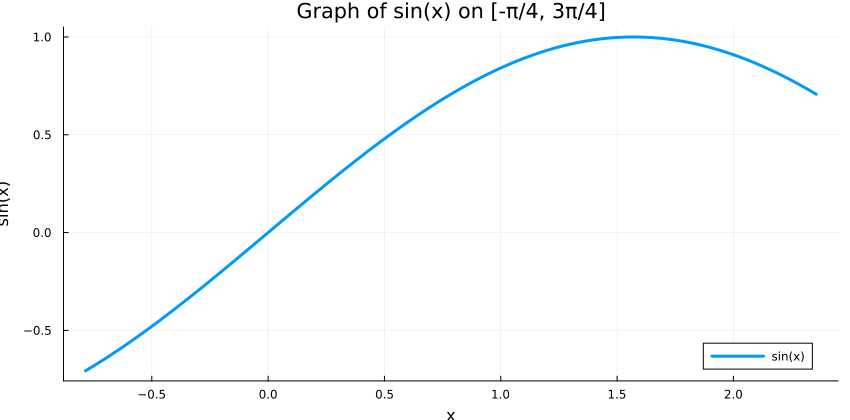

In [2]:
# Plot of sin(x) over the interval [-π/4, 3π/4]

x = range(-pi/4, 3pi/4; length = 400)
y = sin.(x)

plot(
    x,
    y,
    linewidth = 3,
    label = "sin(x)",
    xlabel = "x",
    ylabel = "sin(x)",
    title = "Graph of sin(x) on [-π/4, 3π/4]",
    grid = true,
    legend = :bottomright,
    size = (850, 420)
)


Plot the graph of the function $x\cdot sin(x)$ over the interval $[-10\pi, 10\pi]$

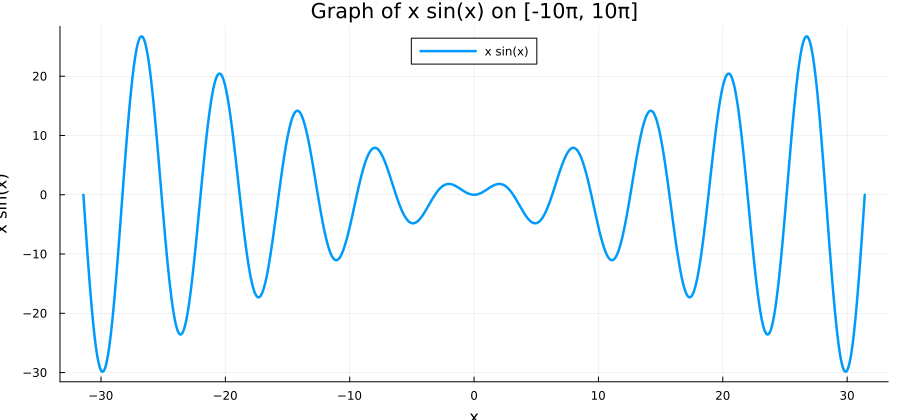

In [3]:
# Plot of x*sin(x) over the interval [-10π, 10π]

x = range(-10pi, 10pi; length = 1200)
y = x .* sin.(x)

plot(
    x,
    y,
    linewidth = 2.5,
    label = "x sin(x)",
    xlabel = "x",
    ylabel = "x sin(x)",
    title = "Graph of x sin(x) on [-10π, 10π]",
    grid = true,
    legend = :top,
    size = (900, 420)
)


# Problem Statement

Solve the Cylinder Problem considering the following data:

* N: 10
* $c_1$: 2
* $c_2$: 0.5
  

In [4]:
# Cylinder Problem
# ----------------------------------------------------------------------
# ATENÇÃO: a fórmula abaixo foi mantida conforme o notebook original
# e o PDF teórico enviado. A linha correspondente no PDF teórico está
# truncada, então RECOMENDA-SE conferir com o slide original da aula.
# Uma forma padrão comum dessa família seria:
#   z = N*pi*r^2*h - c1*pi*r^2 - c2*(2*pi*r^2 + 2*pi*r*h)
# (receita do volume - custo da base - custo da área lateral/total).
# Descomente a versão alternativa se for a correta.
# ----------------------------------------------------------------------

N  = 10.0
c1 = 2.0
c2 = 0.5

model = Model(Ipopt.Optimizer)
set_silent(model)

@variable(model, z)
@variable(model, r >= 0.0, start = 1.0)
@variable(model, h >= 0.0, start = 1.0)

# Versão mantida do notebook original:
@NLconstraint(model,
    z == N*pi*h*r^2 - c1*pi*r^2 - c2*pi*h*(pi*r^2 + 2*pi*r*h)*r^2
)

# Versão alternativa (padrão "receita - base - lateral"), comente a de cima
# e descomente a de baixo caso seja a fórmula do slide:
# @NLconstraint(model,
#     z == N*pi*r^2*h - c1*pi*r^2 - c2*(2*pi*r^2 + 2*pi*r*h)
# )

@objective(model, Max, z)
optimize!(model)

z_opt = objective_value(model)
r_opt = value(r)
h_opt = value(h)
V_opt = pi * r_opt^2 * h_opt

println("Cylinder Problem")
println("----------------")
@printf("Optimal radius  r = %.6f\n", r_opt)
@printf("Optimal height  h = %.6f\n", h_opt)
@printf("Optimal value   z = %.6f\n", z_opt)
@printf("Cylinder volume V = %.6f\n", V_opt)



******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

Cylinder Problem
----------------
Optimal radius  r = 0.825554
Optimal height  h = 1.721467
Optimal value   z = 12.174129
Cylinder volume V = 3.685868


# Problem Statement

Solve the Awning Problem considering the following data:

* h: 2
* w: 3
* initial guess $(x,y) = (1.0, 1.0)$
  

In [5]:
# Awning Problem
# minimize z = sqrt(x^2 + y^2)
# s.t.  y - w*y/x >= h    (equivalente a y*(x-w)/x >= h, exige x > w)
#       x, y > 0
# Obs: o chute (1,1) é INFACTÍVEL pois exige x > w = 3.
# Usamos (5,5), que é factível e próximo do ótimo.

h = 2.0
w = 3.0

model = Model(Ipopt.Optimizer)
set_silent(model)

@variable(model, z)
@variable(model, x >= 1e-6, start = 5.0)
@variable(model, y >= 1e-6, start = 5.0)

@NLconstraint(model, z == sqrt(x^2 + y^2))
@NLconstraint(model, y - w*y/x >= h)

@objective(model, Min, z)
optimize!(model)

x_opt = value(x); y_opt = value(y); z_opt = value(z)

println("Awning Problem")
println("--------------")
@printf("Optimal x = %.6f\n", x_opt)
@printf("Optimal y = %.6f\n", y_opt)
@printf("Minimum z = %.6f\n", z_opt)
@printf("Check y - w*y/x = %.6f  (>= h = %.1f)\n", y_opt - w*y_opt/x_opt, h)


Awning Problem
--------------
Optimal x = 5.289428
Optimal y = 4.620741
Minimum z = 7.023482
Check y - w*y/x = 2.000000  (>= h = 2.0)


# Problem Statement

Solve the Packing Problem

In [6]:
# Packing-Box Problem
# Formulation aligned with the lecture notes:
# maximize z
# subject to
# z = h*w*d
# 2*w*h + 2*h*d + 6*w*d <= 60
# h, w, d >= 0
# with starting point h.l = 1, w.l = 1, d.l = 1

model = Model(Ipopt.Optimizer)
set_silent(model)

@variable(model, z)
@variable(model, h >= 0.0, start = 1.0)
@variable(model, w >= 0.0, start = 1.0)
@variable(model, d >= 0.0, start = 1.0)

@NLconstraint(model, z == h*w*d)
@NLconstraint(model, 2*w*h + 2*h*d + 6*w*d <= 60)

@objective(model, Max, z)

optimize!(model)

h_opt = value(h)
w_opt = value(w)
d_opt = value(d)
z_opt = objective_value(model)

println("Packing-Box Problem")
println("-------------------")
@printf("Optimal h = %.6f\n", h_opt)
@printf("Optimal w = %.6f\n", w_opt)
@printf("Optimal d = %.6f\n", d_opt)
@printf("Maximum z = %.6f\n", z_opt)
@printf("Cardboard used = %.6f\n", 2*w_opt*h_opt + 2*h_opt*d_opt + 6*w_opt*d_opt)


Packing-Box Problem
-------------------
Optimal h = 5.477226
Optimal w = 1.825742
Optimal d = 1.825742
Maximum z = 18.257419
Cardboard used = 60.000000


# Problem Statement

Solve the 3-bus Optimal Power Flow Problem with following data:

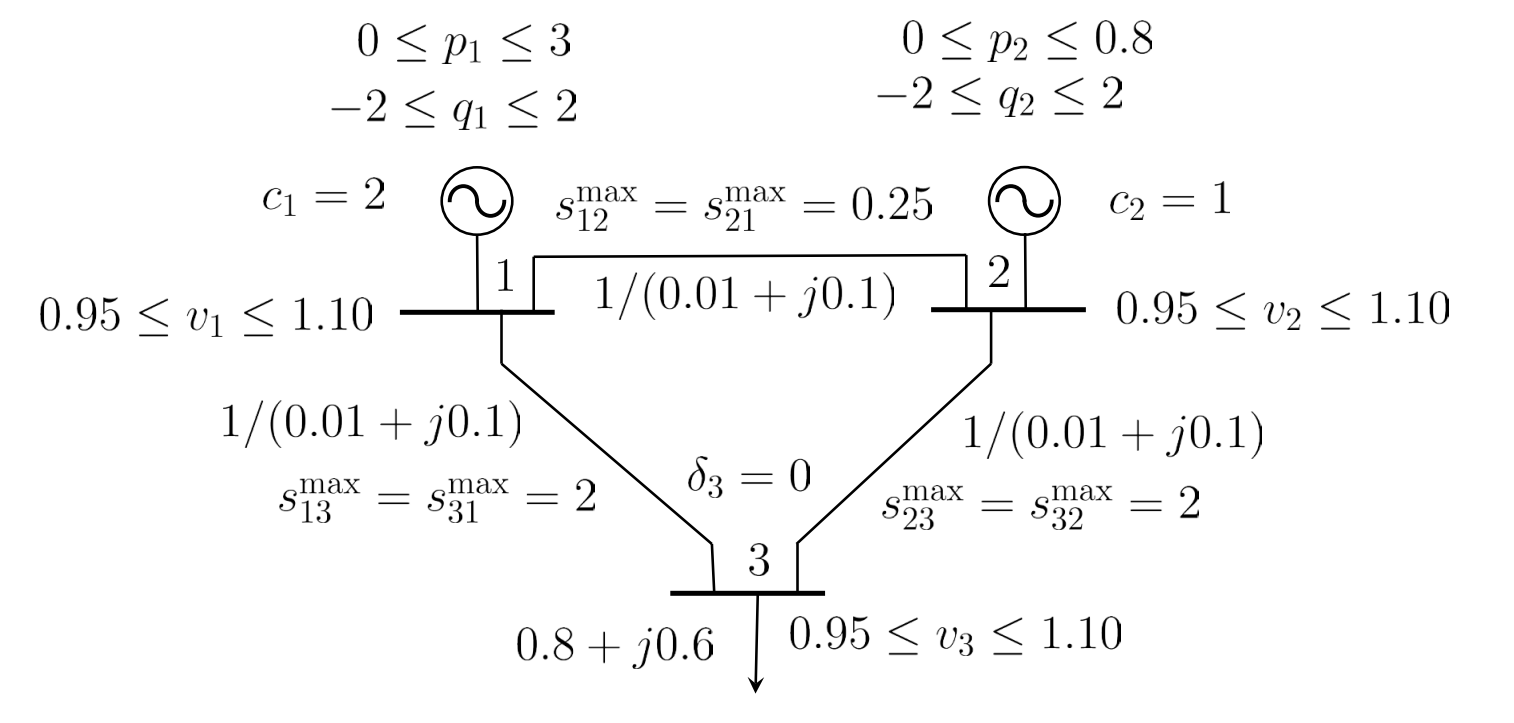

In [7]:
# 3-bus Optimal Power Flow
# Melhoria: usar p^2 + q^2 <= s_max^2 (evita não-diferenciabilidade do sqrt em 0)

c1 = 2.0
c2 = 1.0

dP1, dQ1 = 0.0, 0.0
dP2, dQ2 = 0.0, 0.0
dP3, dQ3 = 0.8, 0.6

Y12 = 1 / (0.01 + 0.1im)
Y13 = 1 / (0.01 + 0.1im)
Y23 = 1 / (0.01 + 0.1im)

yL12, θL12 = abs(Y12), angle(Y12)
yL13, θL13 = abs(Y13), angle(Y13)
yL23, θL23 = abs(Y23), angle(Y23)

yS12 = yS13 = yS23 = 0.0
θS12 = θS13 = θS23 = 0.0

s12max = 0.25; s21max = 0.25
s13max = 2.0 ; s31max = 2.0
s23max = 2.0 ; s32max = 2.0

model = Model(Ipopt.Optimizer)
set_silent(model)

@variable(model, 0.0  <= p1 <= 3.0, start = 0.05)
@variable(model, -2.0 <= q1 <= 2.0, start = 0.30)
@variable(model, 0.0  <= p2 <= 0.8, start = 0.75)
@variable(model, -2.0 <= q2 <= 2.0, start = 0.30)

@variable(model, 0.95 <= v1 <= 1.10, start = 1.09)
@variable(model, 0.95 <= v2 <= 1.10, start = 1.10)
@variable(model, 0.95 <= v3 <= 1.10, start = 1.06)

@variable(model, -pi <= δ1 <= pi, start = 0.02)
@variable(model, -pi <= δ2 <= pi, start = 0.04)
@variable(model, -pi <= δ3 <= pi, start = 0.00)
fix(δ3, 0.0; force = true)

@NLexpression(model, p12,  v1^2*yL12*cos(θL12) - v1*v2*yL12*cos(δ1-δ2-θL12) + 0.5*v1^2*yS12*cos(θS12))
@NLexpression(model, q12, -v1^2*yL12*sin(θL12) - v1*v2*yL12*sin(δ1-δ2-θL12) - 0.5*v1^2*yS12*sin(θS12))
@NLexpression(model, p21,  v2^2*yL12*cos(θL12) - v2*v1*yL12*cos(δ2-δ1-θL12) + 0.5*v2^2*yS12*cos(θS12))
@NLexpression(model, q21, -v2^2*yL12*sin(θL12) - v2*v1*yL12*sin(δ2-δ1-θL12) - 0.5*v2^2*yS12*sin(θS12))
@NLexpression(model, p13,  v1^2*yL13*cos(θL13) - v1*v3*yL13*cos(δ1-δ3-θL13) + 0.5*v1^2*yS13*cos(θS13))
@NLexpression(model, q13, -v1^2*yL13*sin(θL13) - v1*v3*yL13*sin(δ1-δ3-θL13) - 0.5*v1^2*yS13*sin(θS13))
@NLexpression(model, p31,  v3^2*yL13*cos(θL13) - v3*v1*yL13*cos(δ3-δ1-θL13) + 0.5*v3^2*yS13*cos(θS13))
@NLexpression(model, q31, -v3^2*yL13*sin(θL13) - v3*v1*yL13*sin(δ3-δ1-θL13) - 0.5*v3^2*yS13*sin(θS13))
@NLexpression(model, p23,  v2^2*yL23*cos(θL23) - v2*v3*yL23*cos(δ2-δ3-θL23) + 0.5*v2^2*yS23*cos(θS23))
@NLexpression(model, q23, -v2^2*yL23*sin(θL23) - v2*v3*yL23*sin(δ2-δ3-θL23) - 0.5*v2^2*yS23*sin(θS23))
@NLexpression(model, p32,  v3^2*yL23*cos(θL23) - v3*v2*yL23*cos(δ3-δ2-θL23) + 0.5*v3^2*yS23*cos(θS23))
@NLexpression(model, q32, -v3^2*yL23*sin(θL23) - v3*v2*yL23*sin(δ3-δ2-θL23) - 0.5*v3^2*yS23*sin(θS23))

@NLconstraint(model, p1 - dP1 == p12 + p13)
@NLconstraint(model, q1 - dQ1 == q12 + q13)
@NLconstraint(model, p2 - dP2 == p21 + p23)
@NLconstraint(model, q2 - dQ2 == q21 + q23)
@NLconstraint(model,    - dP3 == p31 + p32)
@NLconstraint(model,    - dQ3 == q31 + q32)

# Limites de capacidade (forma quadrática, mais estável que sqrt)
@NLconstraint(model, p12^2 + q12^2 <= s12max^2)
@NLconstraint(model, p21^2 + q21^2 <= s21max^2)
@NLconstraint(model, p13^2 + q13^2 <= s13max^2)
@NLconstraint(model, p31^2 + q31^2 <= s31max^2)
@NLconstraint(model, p23^2 + q23^2 <= s23max^2)
@NLconstraint(model, p32^2 + q32^2 <= s32max^2)

@objective(model, Min, c1*p1 + c2*p2)
optimize!(model)

println("3-bus OPF")
println("---------")
@printf("Optimal cost = %.6f\n", objective_value(model))
@printf("p1 = %.6f, q1 = %.6f\n", value(p1), value(q1))
@printf("p2 = %.6f, q2 = %.6f\n", value(p2), value(q2))
@printf("v1 = %.6f, v2 = %.6f, v3 = %.6f\n", value(v1), value(v2), value(v3))
@printf("δ1 = %.6f, δ2 = %.6f, δ3 = %.6f\n", value(δ1), value(δ2), value(δ3))
@printf("p12=%.4f q12=%.4f | p13=%.4f q13=%.4f | p23=%.4f q23=%.4f\n",
    value(p12),value(q12),value(p13),value(q13),value(p23),value(q23))


3-bus OPF
---------
Optimal cost = 0.836079
p1 = 0.030907, q1 = 0.320917
p2 = 0.774265, q2 = 0.330802
v1 = 1.097700, v2 = 1.100000, v3 = 1.066359
δ1 = 0.021232, δ2 = 0.041913, δ3 = 0.000000
p12=-0.2495 q12=0.0023 | p13=0.2804 q13=0.3186 | p23=0.5243 q23=0.3279


# Problem Statement

Linear Regression with 3 variables.

Consider fi tting a linear model to the following data points with three features:

|      Observation     | $x_1$    | $x_2$    | $x_3$    | Response $(y)$    |
|----------|--------------|--------------|--------------|--------------|
| 1        | 1.0           | 0.5           | 1.2           | 2.0           |
| 2        | 2.0           | 1.0           | 2.1           | 3.9           |
| 3        | 3.0           | 1.5           | 2.9           | 6.1           |
| 4        | 4.0           | 2.0           | 3.8           | 8.0           |
| 5        | 5.0           | 2.5           | 4.5           | 9.8           |

The goal is to find the model $y = \beta_0 + \beta_1x_1 + \beta_2x_2 + \beta_3x_3$ that best fits this data in the least squares sense.

In [8]:
# Linear Regression with 3 variables
# Formulation aligned with the lecture notes:
#
# Minimize  S(β0, β1, β2, β3) =
#     sum( (y_i - (β0 + β1*x_i1 + β2*x_i2 + β3*x_i3))^2 for i = 1,...,n )
#
# This is the least-squares QP formulation shown in the slides.

x1 = [1.0, 2.0, 3.0, 4.0, 5.0]
x2 = [0.5, 1.0, 1.5, 2.0, 2.5]
x3 = [1.2, 2.1, 2.9, 3.8, 4.5]
y  = [2.0, 3.9, 6.1, 8.0, 9.8]

n = length(y)

model = Model(Ipopt.Optimizer)
set_silent(model)

@variable(model, β0, start = 0.0)
@variable(model, β1, start = 0.0)
@variable(model, β2, start = 0.0)
@variable(model, β3, start = 0.0)

@objective(model, Min,
    sum((y[i] - (β0 + β1*x1[i] + β2*x2[i] + β3*x3[i]))^2 for i in 1:n)
)

optimize!(model)

β0_opt = value(β0)
β1_opt = value(β1)
β2_opt = value(β2)
β3_opt = value(β3)

ŷ = [β0_opt + β1_opt*x1[i] + β2_opt*x2[i] + β3_opt*x3[i] for i in 1:n]
residuals = [y[i] - ŷ[i] for i in 1:n]
SSE = objective_value(model)

A = hcat(ones(n), x1, x2, x3)

println("Linear Regression with 3 variables")
println("----------------------------------")
@printf("β0 = %.6f\n", β0_opt)
@printf("β1 = %.6f\n", β1_opt)
@printf("β2 = %.6f\n", β2_opt)
@printf("β3 = %.6f\n", β3_opt)
println()
println("Predicted values:")
println(round.(ŷ, digits = 6))
println()
@printf("Sum of squared errors = %.6f\n", SSE)
println("rank(A) = ", rank(A))
println("Note: rank(A) < 4, so the least-squares minimizer is not unique.")


Linear Regression with 3 variables
----------------------------------
β0 = -0.285455
β1 = 0.272424
β2 = 2.036971
β3 = 0.818182

Predicted values:
[1.987273, 4.014545, 5.96, 7.987273, 9.850909]

Sum of squared errors = 0.035636
rank(A) = 3
Note: rank(A) < 4, so the least-squares minimizer is not unique.


# Problem Statement

A small engineering consulting firm has 3 senior designers available to work on the firm's 4 current projects over the next 2 weeks. Each designer has 80 hours to split among the projects, and the following table shows the manager's scoring $(0=$ nil to $100=$ perfect $)$ of the capability of each designer to contribute to each project, along with his estimate of the hours that each project will require.


|      Designer     | Project 1    | Project 2    | Project 3    | Project 4    |
|----------|--------------|--------------|--------------|--------------|
| 1        | 90           | 80           | 10           | 50           |
| 2        | 60           | 70           | 50           | 65           |
| 3        | 70           | 40           | 80           | 85           |



|     **Required:**      | Project 1    | Project 2    | Project 3    | Project 4    |
|-----------|--------------|--------------|--------------|--------------|
| **Hours** | 70           | 50           | 85           | 35           |


## Model

Let:
- i in {1, 2, 3} denote the designers.
- j in {1, 2, 3, 4} denote the projects.

Define the decision variables x[i,j] >= 0 as the number of hours assigned from designer i to project j.

The score matrix is:

    S = [90  80  10  50
         60  70  50  65
         70  40  80  85]

and the required hours vector is:

    r = [70, 50, 85, 35]

Each designer has at most 80 available hours. Therefore, the LP formulation is:

Maximize

    sum(sum(s[i,j] * x[i,j] for j in 1:4) for i in 1:3)

subject to

    sum(x[i,j] for j in 1:4) <= 80,   for i = 1,2,3

    sum(x[i,j] for i in 1:3) == r[j], for j = 1,2,3,4

    x[i,j] >= 0, for i = 1,2,3 and j = 1,2,3,4

This keeps the same notation and the same equality requirement used in the assignment statement.


## Implement

In [9]:
# Allocation LP
# We keep the same notation used in the assignment:
# x[i,j] = hours assigned from designer i to project j
# s[i,j] = score of designer i on project j
# r[j]   = required hours for project j

s = [
    90 80 10 50
    60 70 50 65
    70 40 80 85
]

r = [70, 50, 85, 35]

model = Model(HiGHS.Optimizer)
set_silent(model)

@variable(model, x[1:3, 1:4] >= 0)

@objective(model, Max, sum(s[i,j] * x[i,j] for i in 1:3, j in 1:4))

@constraint(model, [i in 1:3], sum(x[i,j] for j in 1:4) <= 80)
@constraint(model, [j in 1:4], sum(x[i,j] for i in 1:3) == r[j])

optimize!(model)

println("Allocation LP")
println("-------------")
@printf("Optimal total score = %.2f\n", objective_value(model))
println()
println("Optimal allocation of hours:")
for i in 1:3
    for j in 1:4
        if value(x[i,j]) > 1e-8
            @printf("x[%d,%d] = %.2f\n", i, j, value(x[i,j]))
        end
    end
end


Allocation LP
-------------
Optimal total score = 18825.00

Optimal allocation of hours:
x[1,1] = 70.00
x[1,2] = 10.00
x[2,2] = 40.00
x[2,3] = 5.00
x[2,4] = 35.00
x[3,3] = 80.00


# Problem Statement

A dietitian is planning a meal that meets the daily nutritional requirements for calories, protein, and vitamins at a minimum cost.


|      Food Item     | Cost ($)    | Calories    | Protein (g)    | Vitamins (% Daily)    |
|----------|--------------|--------------|--------------|--------------|
| Apple        | 1              | 100           | 0.5           | 2            |
| Bread        | 0.50           | 200           | 4             | 0            |
| Milk         | 2              | 150           | 8             | 10           |
| Egg          | 0.30           | 70            | 6             | 0            |

Daily nutritional requirements: 500 calories, 50g protein, 100% vitamins.

Define decision variables: $y_1$ for Apples, $y_2$ for Bread, $y_3$ for Milk, $y_4$ for Eggs.  
$y_i$ represents the quantity of each food item.

$$
\begin{aligned}
\text{Minimize} \quad & y_1 + 0.5y_2 + 2y_3 + 0.3y_4 \\
\text{Subject to} \quad 
& 100y_1 + 200y_2 + 150y_3 + 70y_4 \geq 500 \\
& 0.5y_1 + 4y_2 + 8y_3 + 6y_4 \geq 50 \\
& 2y_1 + 0y_2 + 10y_3 + 0y_4 \geq 100 \\
& y_1, y_2, y_3, y_4 \geq 0
\end{aligned}
$$

Ensure all dietary requirements for calories, protein, and vitamins are met.

In [10]:
# Diet Problem
# Same notation as the lecture example:
# y1 = apples, y2 = bread, y3 = milk, y4 = eggs

model = Model(HiGHS.Optimizer)
set_silent(model)

@variable(model, y1 >= 0)
@variable(model, y2 >= 0)
@variable(model, y3 >= 0)
@variable(model, y4 >= 0)

@objective(model, Min, y1 + 0.5y2 + 2y3 + 0.3y4)

@constraint(model, 100y1 + 200y2 + 150y3 + 70y4 >= 500)
@constraint(model, 0.5y1 + 4y2 + 8y3 + 6y4 >= 50)
@constraint(model, 2y1 + 0y2 + 10y3 + 0y4 >= 100)

optimize!(model)

println("Diet Problem")
println("------------")
@printf("Minimum cost = %.2f\n", objective_value(model))
@printf("y1 (Apples) = %.4f\n", value(y1))
@printf("y2 (Bread)  = %.4f\n", value(y2))
@printf("y3 (Milk)   = %.4f\n", value(y3))
@printf("y4 (Eggs)   = %.4f\n", value(y4))


Diet Problem
------------
Minimum cost = 20.00
y1 (Apples) = 0.0000
y2 (Bread)  = 0.0000
y3 (Milk)   = 10.0000
y4 (Eggs)   = 0.0000


# Problem Statement

Consider a hiker who needs to choose the most valuable items for a hike without overloading the backpack.

- Items: Tent (Value: $\$120$, Weight: 2kg), Stove (Value: $\$80$, Weight: 1kg), Food (Value: $\$60$, Weight: 1kg)  
- Backpack capacity: 3.5kg  

Objective: Maximize the value of items in the backpack.

Define binary decision variables: $x_1$ for Tent, $x_2$ for Stove, $x_3$ for Food.  
$x_i = 1$ if the item is chosen, and 0 otherwise.

$$
\begin{aligned}
\text{Maximize} \quad & 120x_1 + 80x_2 + 60x_3 \\
\text{Subject to} \quad 
& 2x_1 + x_2 + x_3 \leq 3.5 \\
& x_1, x_2, x_3 \in \{0,1\}
\end{aligned}
$$

In [11]:
# Knapsack Problem
# Same notation as the lecture example:
# x1 = tent, x2 = stove, x3 = food

model = Model(HiGHS.Optimizer)
set_silent(model)

@variable(model, x1, Bin)
@variable(model, x2, Bin)
@variable(model, x3, Bin)

@objective(model, Max, 120x1 + 80x2 + 60x3)
@constraint(model, 2x1 + x2 + x3 <= 3.5)

optimize!(model)

println("Knapsack Problem")
println("----------------")
@printf("Optimal value = %.2f\n", objective_value(model))
@printf("x1 (Tent)  = %d\n", Int(round(value(x1))))
@printf("x2 (Stove) = %d\n", Int(round(value(x2))))
@printf("x3 (Food)  = %d\n", Int(round(value(x3))))
@printf("Total weight = %.2f\n", 2value(x1) + value(x2) + value(x3))


Knapsack Problem
----------------
Optimal value = 200.00
x1 (Tent)  = 1
x2 (Stove) = 1
x3 (Food)  = 0
Total weight = 3.00
